In [38]:
%load_ext autoreload
%autoreload 2

### 1. 모듈 임포트

In [3]:
import torch
import numpy as np
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features, visualize_feature_grid

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 디바이스 초기화: {device}")

⚙️ Config 설정: Domain Size=2.0, Resolution=128
⚡ 디바이스 초기화: cuda


## 2. 데이터셋 생성

### 2.1 데이터 셋 sdf 생성 및 Poisson Disk 샘플링

In [ ]:
import os
import glob

OUTPUT_DIR = "dataset4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Clean up old single shape files to avoid confusion
old_files = glob.glob(os.path.join(OUTPUT_DIR, "*.npy"))
for f in old_files:
    # os.remove(f)
    print(f"Removed old dataset file: {f}")

DATASET_SIZE = 50
ppc_list = [1, 2, 3, 4] * (DATASET_SIZE // 4)
np.random.shuffle(ppc_list)

generator = SDFGenerator(config)
feature_constructor = FeatureConstruction(dx=config.dx, device=device)

Removed old dataset file: dataset4\particles_000.npy
Removed old dataset file: dataset4\particles_001.npy
Removed old dataset file: dataset4\particles_002.npy
Removed old dataset file: dataset4\particles_003.npy
Removed old dataset file: dataset4\particles_004.npy
Removed old dataset file: dataset4\particles_005.npy
Removed old dataset file: dataset4\particles_006.npy
Removed old dataset file: dataset4\particles_007.npy
Removed old dataset file: dataset4\particles_008.npy
Removed old dataset file: dataset4\particles_009.npy
Removed old dataset file: dataset4\particles_010.npy
Removed old dataset file: dataset4\particles_011.npy
Removed old dataset file: dataset4\particles_012.npy
Removed old dataset file: dataset4\particles_013.npy
Removed old dataset file: dataset4\particles_014.npy
Removed old dataset file: dataset4\particles_015.npy
Removed old dataset file: dataset4\particles_016.npy
Removed old dataset file: dataset4\particles_017.npy
Removed old dataset file: dataset4\particles_0

In [ ]:

START_INDEX = 0  # 🚨 여기서부터 시작합니다.
print(f"\n🚀 Generating {DATASET_SIZE} training samples (SDF + m_c grids)...")

for i in range(START_INDEX, DATASET_SIZE):
    # 🚨 [수정] 무작위로 섞인 리스트에서 이번 차례의 ppc 값을 꺼내옵니다.
    current_ppc = ppc_list[i]
    print(f"\n[{i+1}/{DATASET_SIZE}] Generating shape... (Target PPC: {current_ppc})")
    
    # 1. Generate SDF
    random_shape = generator.create_random_shape(seed=42 + i)
    sdf_grid = generator.to_grid(random_shape)
    
    # 2. Sample Particles
    print(f"  Sampling particles with PPC={current_ppc}...")
    particles = sample_particles_poisson(sdf_grid, config, target_ppc=current_ppc)
    
    # 3. Calculate m_c feature grid
    print("  Calculating m_c features...")
    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)
    grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
    mc_grid = m_c.reshape(grid_shape).cpu().numpy()
    
    # 4. Save
    sdf_filename = os.path.join(OUTPUT_DIR, f"sdf_grid_{i:03d}.npy")
    mc_filename = os.path.join(OUTPUT_DIR, f"mc_grid_{i:03d}.npy")
    
    np.save(sdf_filename, sdf_grid)
    np.save(mc_filename, mc_grid)
    print(f"  Saved: {sdf_filename}, {mc_filename}")

print("\n✅ Dataset generation complete! Files are ready in the 'dataset' folder.")

In [14]:
START_INDEX = 40  
print(f"\n🚀 Generating {DATASET_SIZE} training samples (SDF + Particles)...")

for i in range(START_INDEX, DATASET_SIZE):
    current_ppc = ppc_list[i]
    print(f"\n[{i+1}/{DATASET_SIZE}] Generating shape... (Target PPC: {current_ppc})")
    
    # 1. Generate SDF
    random_shape = generator.create_random_shape(seed=42 + i)
    sdf_grid = generator.to_grid(random_shape)
    
    # 2. Sample Particles
    print(f"  Sampling particles with PPC={current_ppc}...")
    particles = sample_particles_poisson(sdf_grid, config, target_ppc=current_ppc)
    
    # 🚨 [수정 2] m_c 계산 블록 전체 삭제 (저장 단계에서는 불필요함)
    
    # 3. Save SDF and Particles
    sdf_filename = os.path.join(OUTPUT_DIR, f"sdf_grid_{i:03d}.npy")
    # 🚨 [수정 3] mc_grid 대신 particles 파일명으로 변경
    particles_filename = os.path.join(OUTPUT_DIR, f"particles_{i:03d}.npy") 
    
    np.save(sdf_filename, sdf_grid)
    np.save(particles_filename, particles) # 🚨 파티클 원본 배열 저장
    
    print(f"  Saved: {sdf_filename}, {particles_filename}")

print(f"\n✅ Dataset generation complete! Files are ready in the '{OUTPUT_DIR}' folder.")


🚀 Generating 50 training samples (SDF + Particles)...

[41/50] Generating shape... (Target PPC: 4)
  Sampling particles with PPC=4...
   -> 도형 부피 비율: 8.9%
   -> 타겟 PPC: 4 / 고정된 반지름(r): 0.0084
   -> BB 비율: 82.3%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 577895개
  Saved: dataset4\sdf_grid_040.npy, dataset4\particles_040.npy

[42/50] Generating shape... (Target PPC: 4)
  Sampling particles with PPC=4...
   -> 도형 부피 비율: 7.0%
   -> 타겟 PPC: 4 / 고정된 반지름(r): 0.0084
   -> BB 비율: 66.0%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 453332개
  Saved: dataset4\sdf_grid_041.npy, dataset4\particles_041.npy

[43/50] Generating shape... (Target PPC: 4)
  Sampling particles with PPC=4...
   -> 도형 부피 비율: 6.0%
   -> 타겟 PPC: 4 / 고정된 반지름(r): 0.0084
   -> BB 비율: 80.9%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 389481개
  Saved: dataset4\sdf_grid_042.npy, dataset4\particles_042.npy

[44/50] Generating shape... (Target PPC: 1)
  Sampling particles with PPC=1...
   -> 도형 부피 비율: 4.5%
   -> 타겟 PPC: 1 / 고정된 반지름(r): 0.0134
   -> BB 비율: 75.5%
   ->

IndexError: list index out of range

📥 SDF 데이터 로드: dataset4/sdf_grid_001.npy (Shape: (128, 128, 128))
📥 m_c 데이터 로드: dataset4/mc_grid_001.npy (Shape: (128, 128, 128))

[1] 정답(Target) SDF 형상 시각화


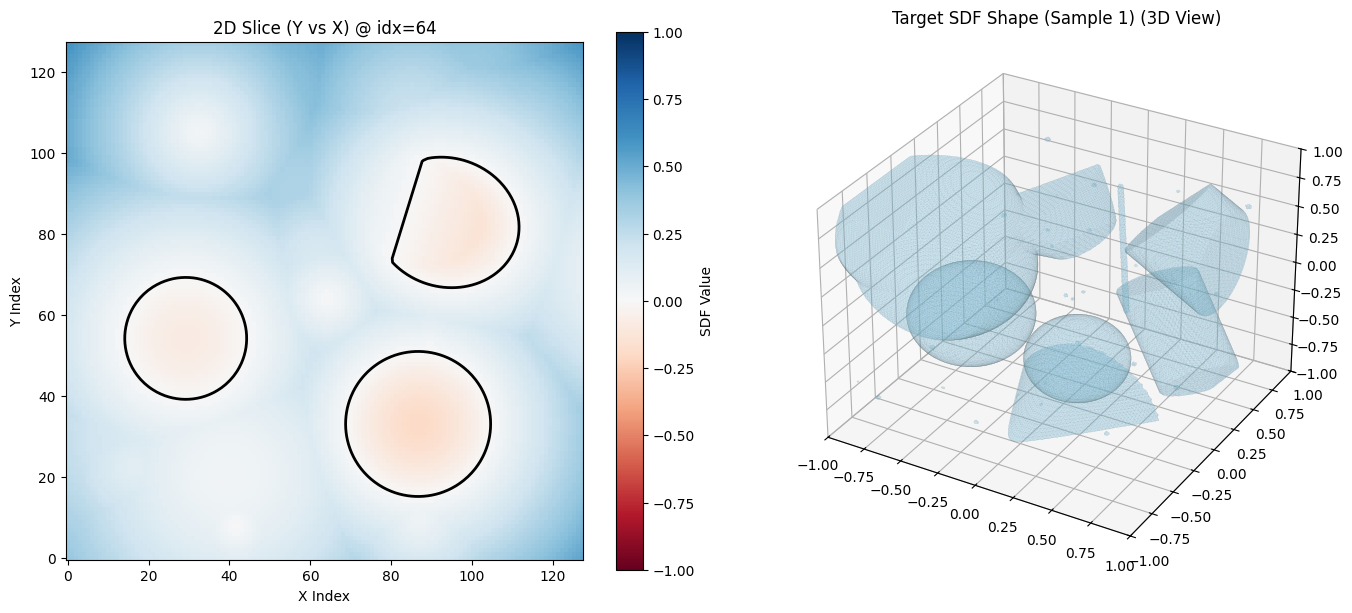


[2] 입력(Input) m_c 특징 공간 시각화


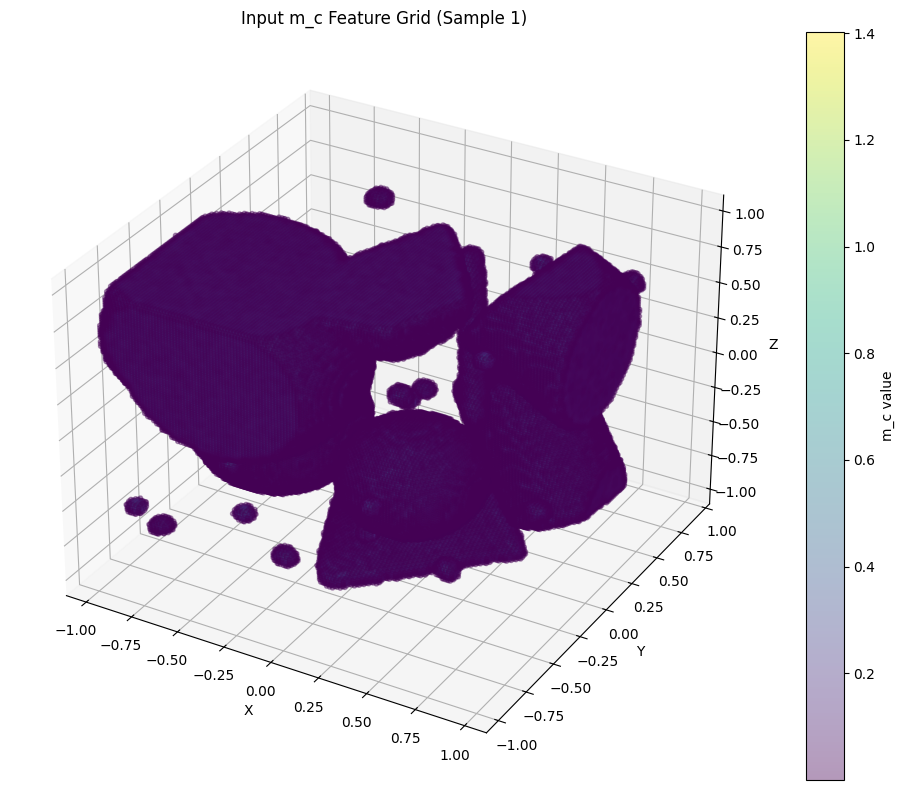

In [7]:
import numpy as np
import torch
from modules.config import config
from modules.visualizer import visualize_simulation, visualize_feature_grid,visualize_particles_and_features

# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sample_idx =1
sdf_file = f"dataset4/sdf_grid_{sample_idx:03d}.npy"
mc_file = f"dataset4/mc_grid_{sample_idx:03d}.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 SDF 데이터 로드: {sdf_file} (Shape: {sdf_grid.shape})")
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

# 3. [시각화 1] Target SDF (원본 3D 지오메트리 형태)
print("\n[1] 정답(Target) SDF 형상 시각화")
visualize_simulation(
    sdf_grid=sdf_grid, 
    domain_size=config.domain_size, 
    title=f"Target SDF Shape (Sample {sample_idx})"
)

# 4. [시각화 2] Input 3D CNN Features (파티클로부터 밀도 단위로 추출된 m_c 값)
print("\n[2] 입력(Input) m_c 특징 공간 시각화")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid (Sample {sample_idx})"
)

In [ ]:
# 1. 기존 Config 설정값 기준
domain_size = config.domain_size
resolution = config.resolution

min_bound = -domain_size / 2.0  # -1.0
max_bound = domain_size / 2.0   # 1.0

# 2. X, Y, Z 축 각각에 대해 -1.0 부터 1.0 까지 64등분한 좌표점 생성
axis_coords = torch.linspace(min_bound, max_bound, resolution)

# 3. 3차원 공간(Meshgrid)으로 확장하여 (64, 64, 64, 3) 형태의 텐서 생성
X, Y, Z = torch.meshgrid(axis_coords, axis_coords, axis_coords, indexing='ij')

# 4. 좌표들을 하나로 묶고 (262144, 3) 형태로 평탄화(Flatten)
grid_nodes = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3)

print(f"✅ 복구된 grid_nodes 형태: {grid_nodes.shape}")

## 3. sdf 계산 -CNN 학습

### 3.1 전처리 단계: 그리드 특징값(m_c) 계산

### 3.2 m_c 값 시각화

In [139]:
import torch
import numpy as np
import os
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features

# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# Phase 1: SDF 도형 생성 및 래스터라이징
# ==========================================
print("\n[Phase 1] 🎲 랜덤 SDF 도형 생성 중...")
# 새로 만든 OOP 클래스를 사용합니다.
generator = SDFGenerator(config)

random_sdf = generator.create_sample_shape() 
sdf_grid = generator.to_grid(random_sdf)

print(f"✅ SDF Grid 생성 완료: Shape={sdf_grid.shape}")

# ==========================================
# Phase 2: Poisson Disk 샘플링
# ==========================================
print("\n[Phase 2] 🎯 파티클 샘플링 중...")
# config 객체를 두 번째 인자로 넘겨받도록 변경된 부분을 반영합니다.
particles = sample_particles_poisson(sdf_grid, config)

print(f"✅ 파티클 샘플링 완료: {len(particles)}개 생성됨 (목표: {config.num_particles}개)")

# ==========================================
# Phase 3: 특징 인코딩 (Feature Construction)
# ==========================================
print("\n[Phase 3] 🧠 모델 입력용 특징(m_c) 추출 중...")
# 함수형 형태를 유지한 원본 FeatureConstruction을 사용하되, dx는 config 참조
feature_constructor = FeatureConstruction(dx=config.dx, device=device)

particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)

# 파티클 위치 기반으로 동적 그리드 변환 
grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
m_c_grid = m_c.reshape(grid_shape).cpu().numpy()

print(f"✅ 기하학적 특징 추출 완료")
print(f"   - Grid Shape: {grid_shape}")
print(f"   - m_c 통계: Min={m_c.min():.4f}, Max={m_c.max():.4f}")

# ==========================================
# Phase 4: 데이터 저장 (.npy)
# ==========================================
print("\n[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...")

# 출력 폴더 생성 (선택 사항, 깔끔한 관리를 위해)
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# 텐서로 남아있는 grid_nodes를 numpy로 변환
grid_nodes_np = grid_nodes.cpu().numpy() if isinstance(grid_nodes, torch.Tensor) else grid_nodes

# 각각 .npy 파일로 저장
np.save(os.path.join(save_dir, "sdf_grid_128.npy"), sdf_grid)
np.save(os.path.join(save_dir, "particles_128.npy"), particles)
np.save(os.path.join(save_dir, "mc_grid_128.npy"), m_c_grid)
# np.save(os.path.join(save_dir, "grid_nodes_64.npy"), grid_nodes_np)

print(f"✅ 모든 데이터 저장 완료! (저장 위치: ./{save_dir}/)")



⚙️ Config 설정: Domain Size=2.0, Resolution=128

[Phase 1] 🎲 랜덤 SDF 도형 생성 중...
✅ SDF Grid 생성 완료: Shape=(128, 128, 128)

[Phase 2] 🎯 파티클 샘플링 중...
   -> 도형 부피 비율: 17.0%
   -> 타겟 PPC: 3.0 / 고정된 반지름(r): 0.0093
   -> BB 비율: 43.3%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 833801개
✅ 파티클 샘플링 완료: 833801개 생성됨 (목표: 40000개)

[Phase 3] 🧠 모델 입력용 특징(m_c) 추출 중...
✅ 기하학적 특징 추출 완료
   - Grid Shape: (128, 128, 128)
   - m_c 통계: Min=0.0000, Max=1.2382

[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...
✅ 모든 데이터 저장 완료! (저장 위치: ././/)



[Phase 4] 📊 프로세스 검증용 데이터 시각화


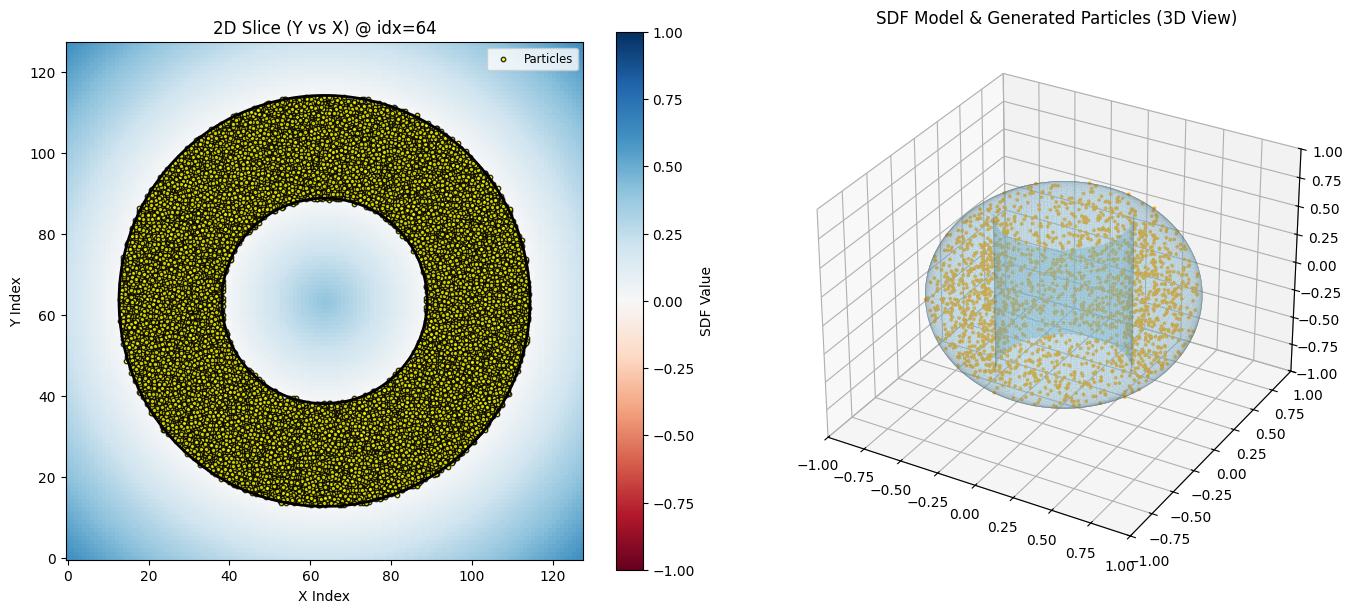

c:\Users\user00\Desktop\yubin\reconstruction\modules\visualizer.py:368: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


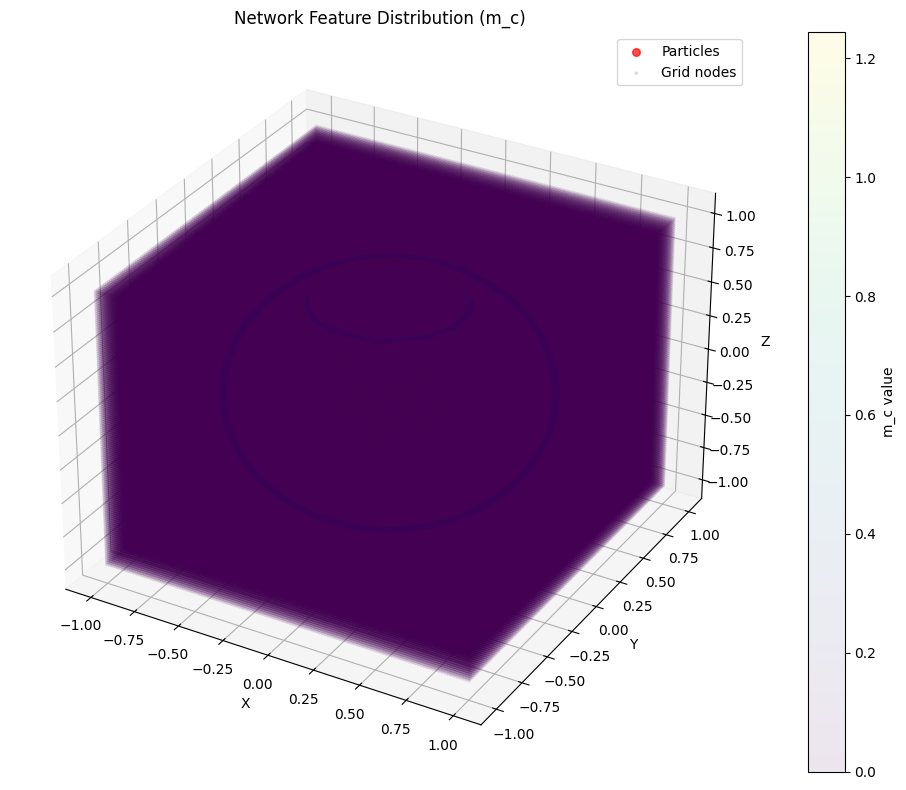

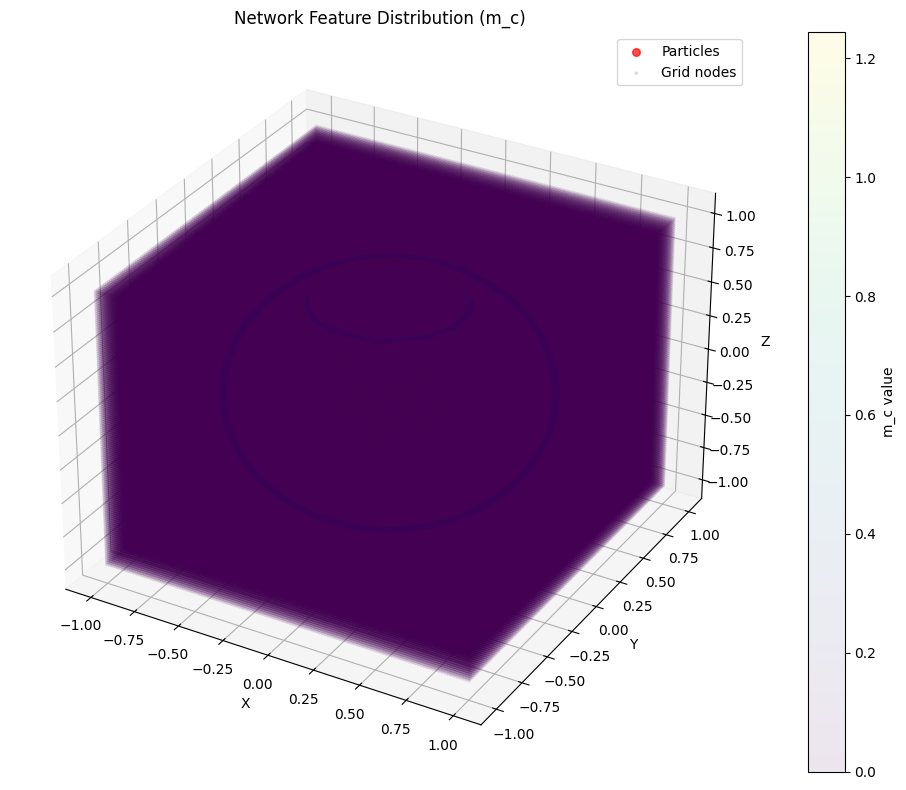

In [66]:

# ==========================================
# Phase 5: 시각화 모듈
# ==========================================
print("\n[Phase 4] 📊 프로세스 검증용 데이터 시각화")

# 4-1. 전반적인 형상 + 파티클 위치 뷰어
visualize_simulation(
    sdf_grid=sdf_grid, 
    particles=particles, 
    domain_size=config.domain_size, 
    title="SDF Model & Generated Particles"
)

# 4-2. 파티클 분포와 네트워크의 m_c 추출 결과 뷰어
visualize_particles_and_features(
    particles=particles_tensor.cpu(),
    grid_nodes=grid_nodes.cpu(),
    m_c_grid=m_c_grid,
    title="Network Feature Distribution (m_c)"
)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from modules.config import config
from modules.particle_sampler import sample_particles_poisson
from modules.visualizer import visualize_simulation

print("=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===")

# 1. 원본 SDF 데이터 불러오기
file_path = "sdf_grid_64.npy"
try:
    sdf_grid = np.load(file_path)
    print(f"✅ 데이터 로드 성공: {file_path} (Shape: {sdf_grid.shape})")
except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다: {file_path}")
    sdf_grid = None
    
if sdf_grid is not None:
    # 2. 파티클 샘플링
    print("\n[파티클 샘플링 중...]")
    particles = sample_particles_poisson(sdf_grid, config)
    print(f"✅ 추출된 파티클 갯수: {len(particles)}")
    # 3. 파티클 위치 기반으로 동적 그리드 변환 및 m_c 계산
    print("\n[DirectML 가속으로 m_c 특징값 계산 중...]")
    feature_constructor = FeatureConstruction(dx=config.dx, device=device)
    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)
    
    # 🌟 기존에 구현되어 있는 통합 함수 호출!
    grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
    
    # 3D 텐서(64x64x64)로 복원 후 numpy 배열로 변환
    mc_grid = m_c.reshape(grid_shape).cpu().numpy()
    
    # 4. 결과 저장 (mc_grid_64.npy)
    save_path = "mc_grid_64.npy"
    # np.save(save_path, mc_grid)
    print(f"✅ m_c 그리드 저장 완료: {save_path} (Shape: {mc_grid.shape})")
    # 5. m_c 3D 특징 맵 시각화
    print("\n[m_c 특징 공간 시각화]")
    fig = visualize_feature_grid(
        m_c_grid=m_c,             # flatten된 1D 텐서 그대로 투입
        grid_nodes=grid_nodes,    # 짝이 완벽하게 맞는 3D 좌표 노드
        title="Computed m_c Feature Grid (from sdf_grid_64.npy)"
    )
    plt.show()

=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===
✅ 데이터 로드 성공: sdf_grid_64.npy (Shape: (64, 64, 64))

[파티클 샘플링 중...]
   -> 도형 부피 비율: 16.6%
   -> 타겟 PPC: 3.0 / 고정된 반지름(r): 0.0093


KeyboardInterrupt: 

📥 m_c 데이터 로드: mc_grid.npy (Shape: (128, 128, 128))


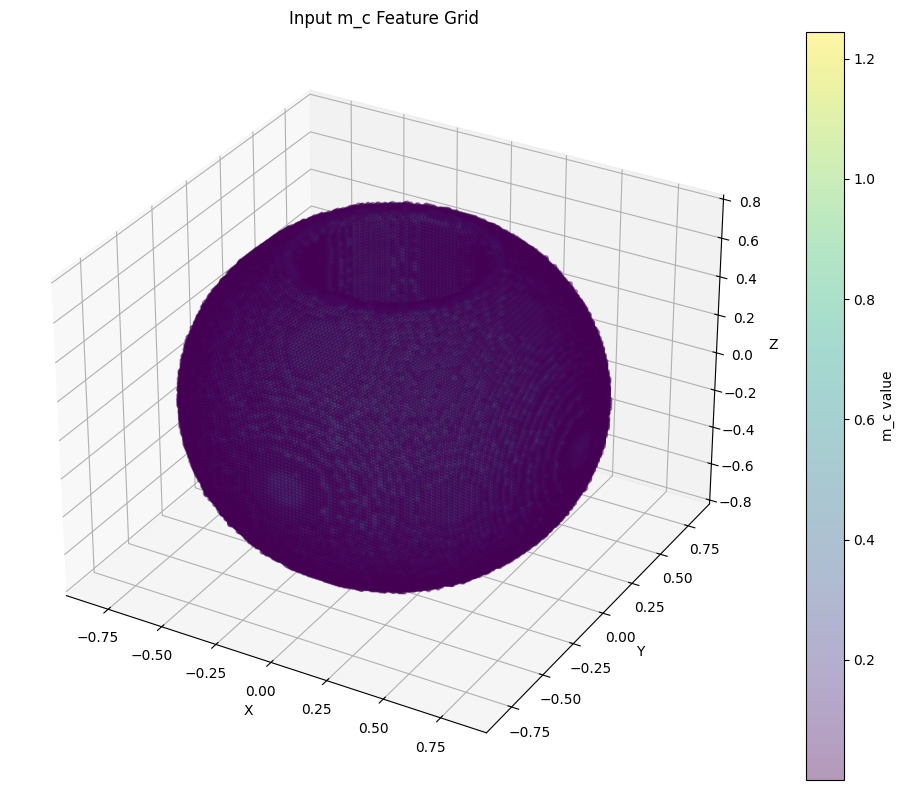

In [67]:
# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sdf_file = f"sdf_grid.npy"
mc_file = f"mc_grid.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid"
)

### 3.3 3D CNN 네트워크를 통한 SDF 값 추론

### 3.4 학습

디바이스/데이터로더 설정 셀

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F

# 모듈 임포트는 유저님 환경에 맞게 유지
from modules.sdf_network import SDFNetwork
from modules.dataset import SDFDataset
from modules.sdf_network import PolynomialRegularizedSDFLoss

# ==========================================
# 🚨 1. DirectML 개입 원천 차단 및 순수 CPU 강제 고정
# ==========================================
# device = torch.device('cpu')
# print(f"🔒 현재 강제 고정된 디바이스: {device}")

# 2. 데이터로더 생성 (배치 사이즈는 메모리에 맞게 조절)
print("데이터를 불러옵니다...")
train_dataset = SDFDataset(
    data_dir="dataset3", 
    patch_size=8,
    in_memory=True, 
    use_narrow_band=True, 
    use_bg_sample=False,     # 스위치 켜고 끄기가 메인 코드에 바로 보임
    bg_sample_ratio=0.10
)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

# 3. 모델 및 옵티마이저 생성 (모델을 강제로 CPU로!)
model = SDFNetwork().to(device)
model.float() # 강제 float32 포맷팅
model.train()

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = PolynomialRegularizedSDFLoss(lambda_reg=1.0).to(device)

데이터를 불러옵니다...
💾 데이터를 메모리에 캐싱 중입니다...
✅ 캐싱 완료.
🔍 [초고속 필터링] 표면(|SDF| <= 0.0312) 샘플링 중...
✅ 샘플링 완료!
   - 표면(Narrow Band) 데이터: 11635147개 (100% 사용)
   - 최종 학습 데이터: 11635147개 (전체 중 5.5%)


훈련 반복문 셀

In [24]:
import time
import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

# 🚨 유저님의 실제 모듈 구조에 맞춘 완벽한 임포트
from modules.dataset import SDFDataset, DataLoader
from modules.sdf_network import SDFNetwork, PolynomialRegularizedSDFLoss, SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 작동 디바이스: {device}")

# ==========================================
# 📦 1. 데이터 로드 (Narrow Band 적용)
# ==========================================
print("\n[데이터 로드 시작]")

# 🚨 메인 스크립트에서 내가 원하는 대로 직관적으로 세팅!
train_dataset = SDFDataset(
    data_dir="dataset3", 
    patch_size=8,
    in_memory=True, 
    use_narrow_band=True, 
    use_bg_sample=False,     # 스위치 켜고 끄기가 메인 코드에 바로 보임
    bg_sample_ratio=0.10
)

# 데이터로더로 포장
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)


⚡ 작동 디바이스: cuda

[데이터 로드 시작]
💾 데이터를 메모리에 캐싱 중입니다...
✅ 캐싱 완료.
🔍 [초고속 필터링] 표면(|SDF| <= 0.0312) 샘플링 중...
✅ 샘플링 완료!
   - 표면(Narrow Band) 데이터: 11635147개 (100% 사용)
   - 최종 학습 데이터: 11635147개 (전체 중 5.5%)


In [25]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 사용자 정의 모듈 임포트 (경로는 본인 환경에 맞게 유지)
from modules.sdf_network import SDFNetwork, SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

print("=== [Step 5] 저장된 가중치 불러오기 및 다이렉트 SDF 추론 ===")

# -------------------------------------------------------------------
# [핵심 수정 사항] 진짜 신경망 모델(SDFNetwork)을 불러옵니다!
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 빈 모델 껍데기(구조) 생성
model = SDFNetwork().to(device)

# 2. 가중치 파일 경로 및 로드
weights_path = "sdf_network_cpu.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))

# 3. 평가(eval) 모드로 전환
model.eval()

print(f"✅ '{weights_path}' 가중치 로드 완료! (Device: {device})")


=== [Step 5] 저장된 가중치 불러오기 및 다이렉트 SDF 추론 ===


C:\Users\user00\AppData\Local\Temp\ipykernel_26356\3900679197.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_locatio

RuntimeError: Error(s) in loading state_dict for SDFNetwork:
	size mismatch for fc3.weight: copying a param with shape torch.Size([1, 128]) from checkpoint, the shape in current model is torch.Size([27, 128]).
	size mismatch for fc3.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([27]).

In [28]:

# 추론 및 시각화를 위한 평가용 데이터 로드
m_c_grid_np = np.load("sample/mc_grid.npy")
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)
sdf_grid_gt = np.load("sample/sdf_grid.npy")  # 정답지 (비교용)

# 공통 학습 파라미터 세팅 (빠른 실험을 위해 데이터의 50%만 학습)
num_epochs = 5
max_batches = len(train_loader) // 5

In [29]:

# ==========================================
# 🧪 [실험 1] 다항식 정규화(Polynomial) + MSE 모드 (논문 세팅)
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작")
print("="*55)

model_poly = SDFNetwork().to(device)
optimizer_poly = optim.Adam(model_poly.parameters(), lr=0.0002)
# 🚨 use_poly_loss=True (정규화 ON)
criterion_poly = PolynomialRegularizedSDFLoss(lambda_reg=1.0, use_poly_loss=True).to(device)

start_time = time.time()
model_poly.train_step(
    train_loader=train_loader,
    optimizer=optimizer_poly,
    criterion=criterion_poly,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 1 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")


print(">> 실험 1 초고속 추론 중...")
reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
reconstructor_poly.network = model_poly  # 학습된 모델 장착
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)




>> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작


Epoch [01/05]:  20%|██        | 9090/45450 [03:36<14:25, 42.03it/s, loss=0.00010]


✅ Epoch 1 완료! 평균 Loss: 0.001077



Epoch [02/05]:  20%|██        | 9090/45450 [03:37<14:28, 41.86it/s, loss=0.00002]


✅ Epoch 2 완료! 평균 Loss: 0.000039



...

✅ Epoch 3 완료! 평균 Loss: 0.000016



Epoch [04/05]:  20%|██        | 9090/45450 [03:35<14:22, 42.16it/s, loss=0.00001]


✅ Epoch 4 완료! 평균 Loss: 0.000014



Epoch [05/05]:  20%|██        | 9090/45450 [03:37<14:29, 41.82it/s, loss=0.00001]


✅ Epoch 5 완료! 평균 Loss: 0.000013

✅ 실험 1 학습 완료! (소요 시간: 1084.2초)
>> 실험 1 초고속 추론 중...


In [30]:
# ==========================================
# 🧪 [실험 2] 순수 MSE 모드 (정규화 제거 비교용)
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)")
print("="*55)

# 🚨 이전 모델의 기억을 지우고 완전히 새로운 모델 생성
model_mse = SDFNetwork().to(device)
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.0002)
# 🚨 use_poly_loss=False (정규화 OFF)
criterion_mse = PolynomialRegularizedSDFLoss(use_poly_loss=False).to(device)

start_time = time.time()
model_mse.train_step(
    train_loader=train_loader,
    optimizer=optimizer_mse,
    criterion=criterion_mse,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 2 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")

print(">> 실험 2 초고속 추론 중...")
reconstructor_mse = SDFReconstruction(dx=config.dx, device=device)
reconstructor_mse.network = model_mse  # 두 번째로 학습된 모델 장착
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)




>> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)


Epoch [01/05]:  20%|██        | 9090/45450 [03:36<14:24, 42.05it/s, loss=0.00002]


✅ Epoch 1 완료! 평균 Loss: 0.000101



Epoch [02/05]:  20%|██        | 9090/45450 [03:36<14:27, 41.93it/s, loss=0.00002]


✅ Epoch 2 완료! 평균 Loss: 0.000018



...

✅ Epoch 3 완료! 평균 Loss: 0.000015



Epoch [04/05]:  20%|██        | 9090/45450 [03:36<14:26, 41.96it/s, loss=0.00001]


✅ Epoch 4 완료! 평균 Loss: 0.000014



Epoch [05/05]:  20%|██        | 9090/45450 [03:36<14:27, 41.91it/s, loss=0.00001]


✅ Epoch 5 완료! 평균 Loss: 0.000013

✅ 실험 2 학습 완료! (소요 시간: 1083.8초)
>> 실험 2 초고속 추론 중...


In [44]:
print(">> 실험 1 초고속 추론 중...")
reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
reconstructor_poly.network = model_poly  # 학습된 모델 장착
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048, use_pruning = True)

print(">> 실험 2 초고속 추론 중...")
reconstructor_mse = SDFReconstruction(dx=config.dx, device=device)
reconstructor_mse.network = model_mse  # 두 번째로 학습된 모델 장착
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048, use_pruning = True)

>> 실험 1 초고속 추론 중...
   ✂️ [Pruning ON] 2097152개 중 730107개 노드 연산 (34.8%)
>> 실험 2 초고속 추론 중...
   ✂️ [Pruning ON] 2097152개 중 730107개 노드 연산 (34.8%)



=== [Step 6] 결과물 시각화 (Ablation 비교) ===


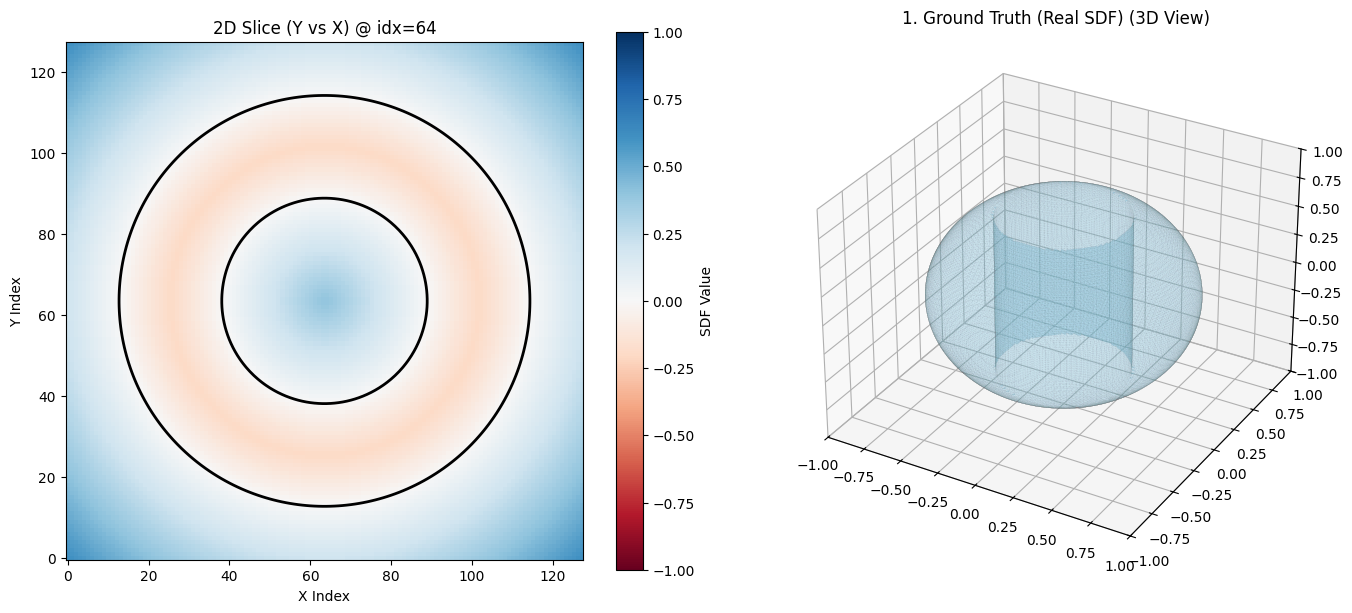

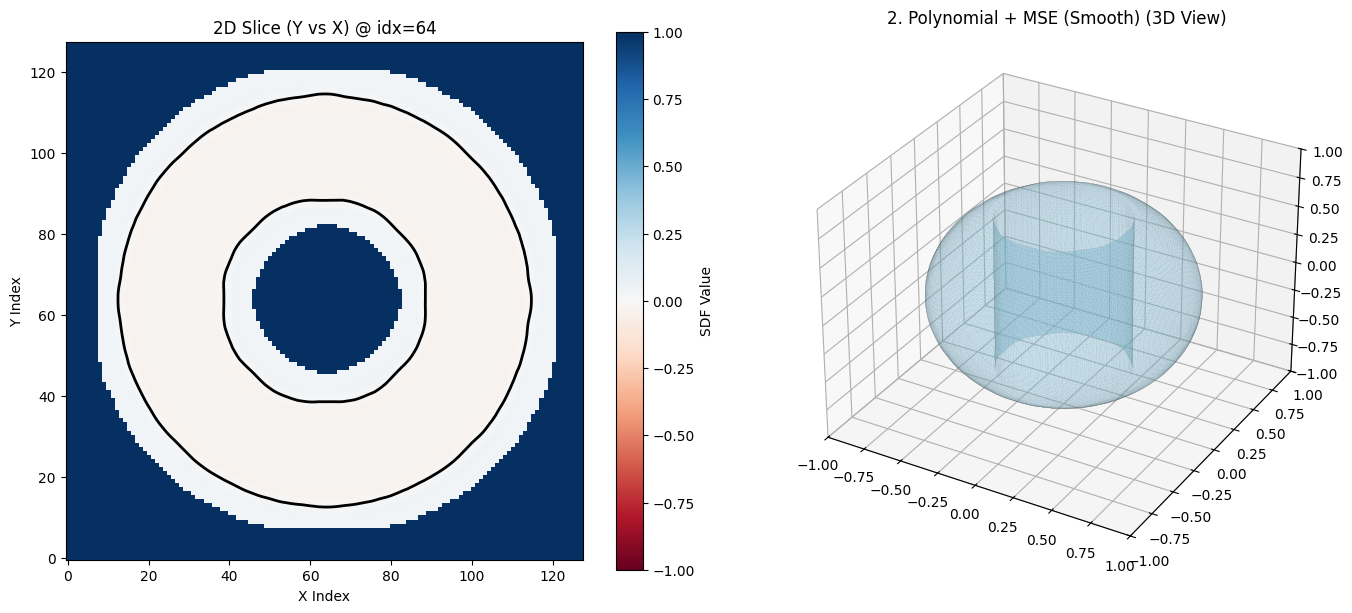

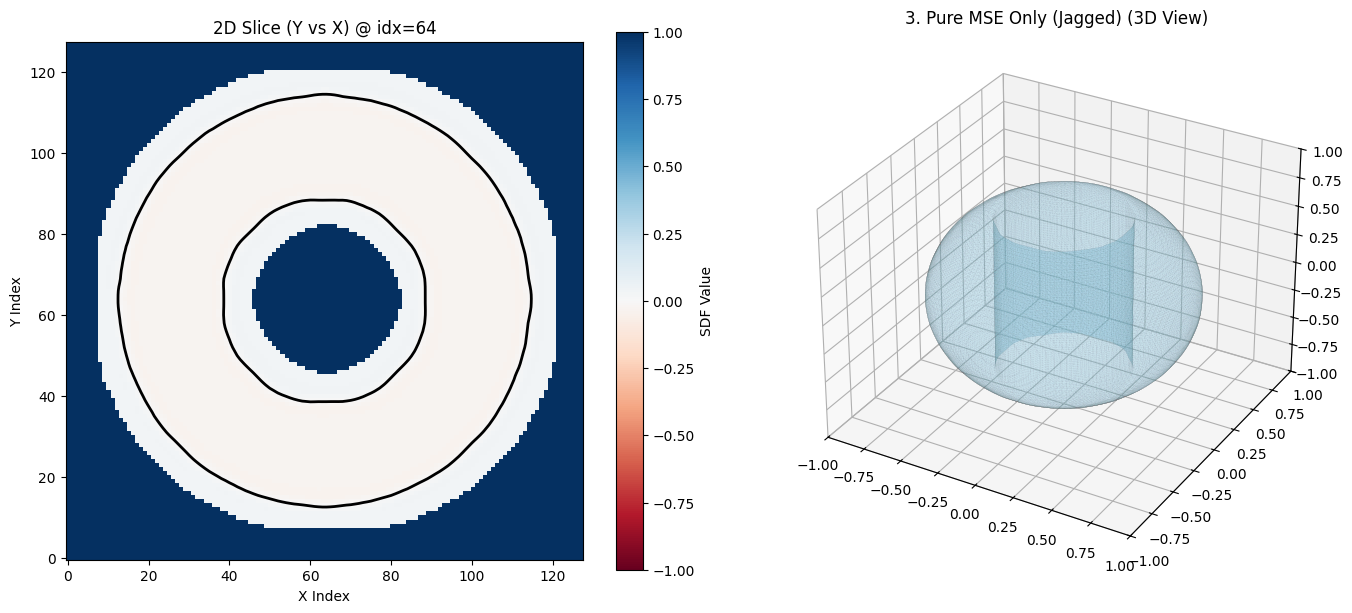

In [45]:

# ==========================================
# 📊 최종 결과 시각화 및 비교
# ==========================================
print("\n=== [Step 6] 결과물 시각화 (Ablation 비교) ===")

# 1. 정답지 (도넛 모양)
visualize_simulation(sdf_grid=sdf_grid_gt, domain_size=config.domain_size, title="1. Ground Truth (Real SDF)")

# 2. 논문 세팅 결과 (매끄러운 곡면)
visualize_simulation(sdf_grid=pred_sdf_poly.cpu().numpy(), domain_size=config.domain_size, title="2. Polynomial + MSE (Smooth)")

# 3. 정규화 끈 결과 (쭈글쭈글한 표면)
visualize_simulation(sdf_grid=pred_sdf_mse.cpu().numpy(), domain_size=config.domain_size, title="3. Pure MSE Only (Jagged)")

In [46]:
# 1. 평가용 데이터 로드 
# 🚨 핵심 변경: mc_grid.npy 대신 원본 파티클 좌표를 직접 불러옵니다!
particles_np = np.load("sample/particles_128.npy")
particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)

sdf_grid_gt = np.load("sample/sdf_grid.npy")  # 정답지 (기본 해상도, 비교용)

print("\n" + "="*55)
print(">> 🎯 [실험 1] Poly 모델 고해상도(Staggered) 추론 시작")
print("="*55)
reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
reconstructor_poly.network = model_poly  # 첫 번째로 학습된 모델 장착

start_time = time.time()
# 🚨 inference 대신 staggered_inference 호출!
# 내부적으로 Pruning이 8번 작동하여 연산 속도를 크게 단축시킵니다.
pred_sdf_poly_high_res = reconstructor_poly.staggered_inference(
    particles_tensor, 
    patch_size=8, 
    batch_size=2048
)
print(f"   -> ⏱️ Poly 모델 총 소요 시간: {time.time() - start_time:.1f}초\n")


print("="*55)
print(">> 🎯 [실험 2] MSE 모델 고해상도(Staggered) 추론 시작")
print("="*55)
reconstructor_mse = SDFReconstruction(dx=config.dx, device=device)
reconstructor_mse.network = model_mse  # 두 번째로 학습된 모델 장착

start_time = time.time()
pred_sdf_mse_high_res = reconstructor_mse.staggered_inference(
    particles_tensor, 
    patch_size=8, 
    batch_size=2048
)
print(f"   -> ⏱️ MSE 모델 총 소요 시간: {time.time() - start_time:.1f}초\n")


>> 🎯 [실험 1] Poly 모델 고해상도(Staggered) 추론 시작
🚀 [Staggered Reconstruction] 고해상도(2배) 레벨셋 복원을 시작합니다...
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 730084개 노드 연산 (34.8%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 732975개 노드 연산 (35.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 731612개 노드 연산 (34.9%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 733186개 노드 연산 (35.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 731591개 노드 연산 (34.9%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 733180개 노드 연산 (35.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=1, c=0 (Offset: (0.007874015748031496, 0.007874015748031496, 0.

=== 📊 고해상도 결과물 시각화 ===
💡 참고: Ground Truth는 기본 해상도(N)이며, 예측 결과는 2배 해상도(2N)입니다.


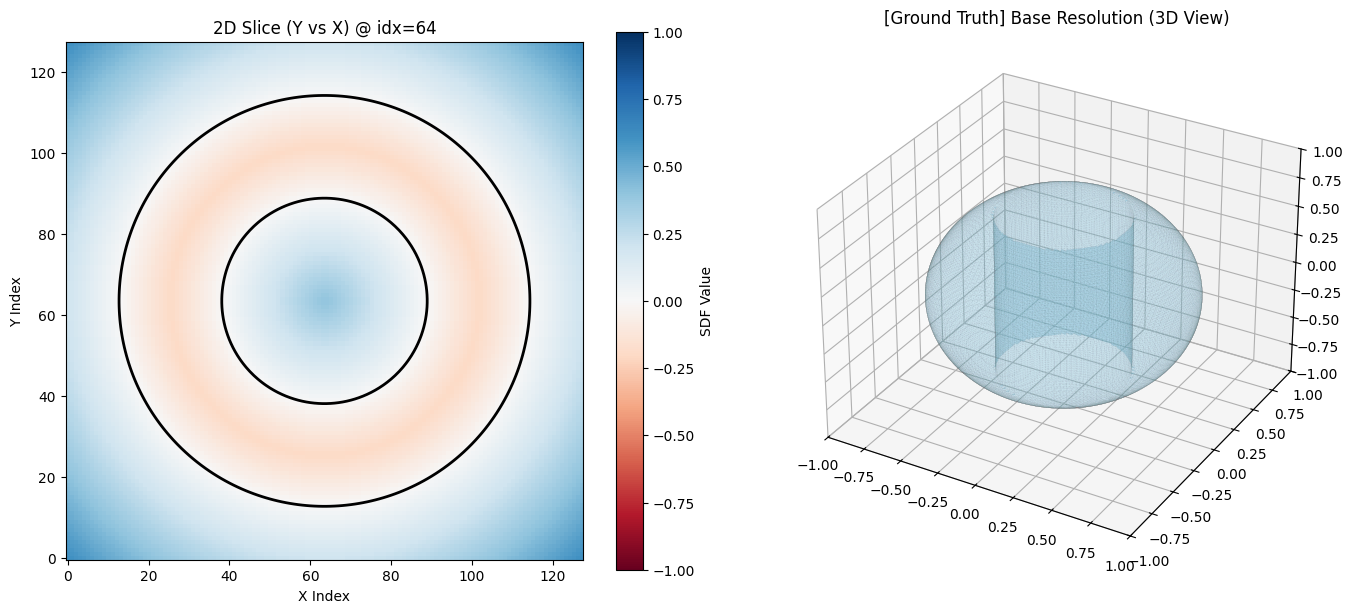

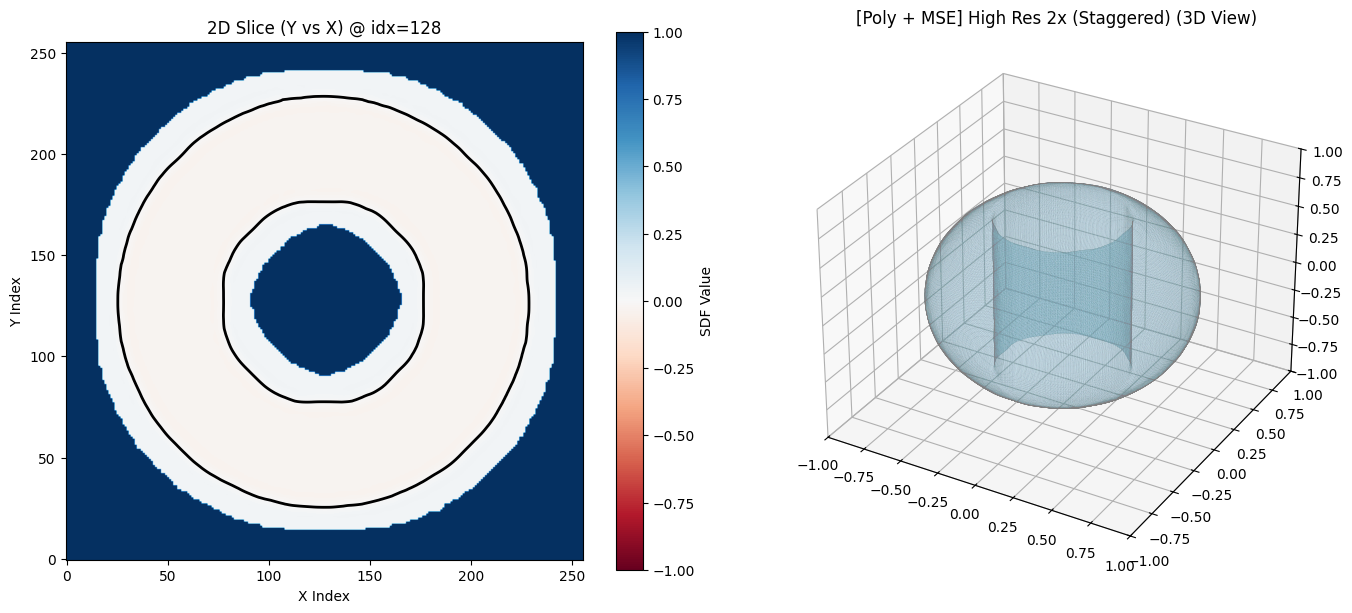

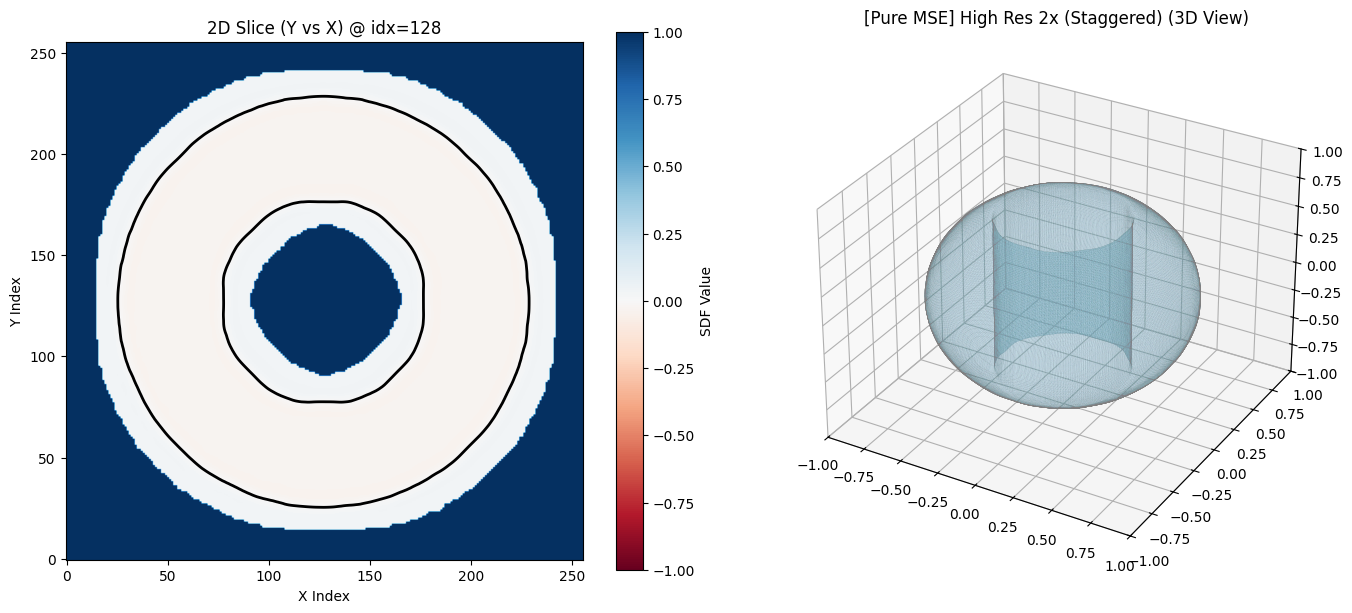

In [47]:
# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print("=== 📊 고해상도 결과물 시각화 ===")
print("💡 참고: Ground Truth는 기본 해상도(N)이며, 예측 결과는 2배 해상도(2N)입니다.")

# 1. 정답지 (기본 해상도)
visualize_simulation(
    sdf_grid=sdf_grid_gt, 
    domain_size=config.domain_size, 
    title="[Ground Truth] Base Resolution"
)

# 2. 논문 세팅 결과 (2배 해상도 + 정규화로 매우 매끄러움)
visualize_simulation(
    sdf_grid=pred_sdf_poly_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title="[Poly + MSE] High Res 2x (Staggered)"
)

# 3. 정규화 끈 결과 (2배 해상도지만 표면이 울퉁불퉁할 수 있음)
visualize_simulation(
    sdf_grid=pred_sdf_mse_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title="[Pure MSE] High Res 2x (Staggered)"
)

In [23]:
# ==========================================
# 🎯 [추가 실험] 특정 데이터 추론 및 비교
# ==========================================
# 🚨 여기서 원하는 데이터의 인덱스 번호만 바꾸면 끝입니다! (예: 1, 9, 10)
target_idx = 10  

# 0을 채워서 자동으로 3자리 문자열로 만듭니다. (예: 1 -> "001", 15 -> "015")
shape_name = f"{target_idx:03d}" 

print("\n" + "="*55)
print(f">> 🎯 특정 테스트 데이터(Shape {shape_name}) 추론 시작")
print("="*55)

# 1. 지정된 타겟 & 특징 그리드 로드 (전처리 완전 생략!)
# 파일 경로가 자동으로 세팅됩니다.
sdf_path = f"dataset3/sdf_grid_{shape_name}.npy"
mc_path = f"dataset3/mc_grid_{shape_name}.npy"

target_sdf = np.load(sdf_path)
m_c_grid_np = np.load(mc_path)

# 텐서 변환
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)

# 2. [Poly 모드] 이미 학습된 Poly 모델로 초고속 추론
print(f">> Poly 모델(정규화 ON)로 Shape {shape_name} 추론 중...")
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# 3. [MSE 모드] 이미 학습된 MSE 모델로 초고속 추론
print(f">> MSE 모델(정규화 OFF)로 Shape {shape_name} 추론 중...")
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 7] Shape {shape_name} 결과물 시각화 (Unseen Data Test) ===")

# 1. 정답지 (진짜 모습)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Ground Truth"
)

# 2. 논문 세팅 결과 (정규화가 들어간 매끄러운 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_poly.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Polynomial + MSE (Smooth)"
)

# 3. 정규화 끈 결과 (정규화가 없을 때의 쭈글쭈글한 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_mse.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Pure MSE Only (Jagged)"
)


>> 🎯 특정 테스트 데이터(Shape 010) 추론 시작
>> Poly 모델(정규화 ON)로 Shape 010 추론 중...


NameError: name 'reconstructor_poly' is not defined


>> 🎯 특정 테스트 데이터(Shape 010) 고해상도(2배) 추론 시작
>> Poly 모델(정규화 ON)로 Shape 010 고해상도 뻥튀기 중...
🚀 [Staggered Reconstruction] 고해상도(2배) 레벨셋 복원을 시작합니다...
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 574792개 노드 연산 (27.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 573485개 노드 연산 (27.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 573022개 노드 연산 (27.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 569837개 노드 연산 (27.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 574255개 노드 연산 (27.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 571769개 노드 연산 (27.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=1, c=0 (Offset: (0.

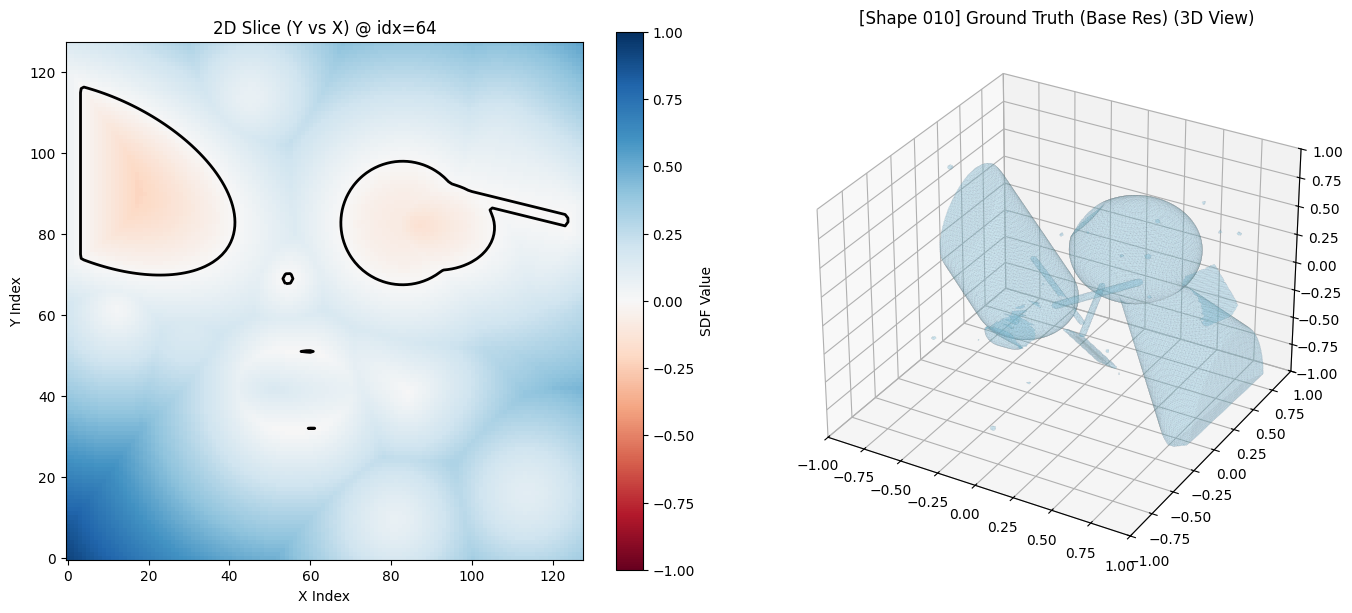

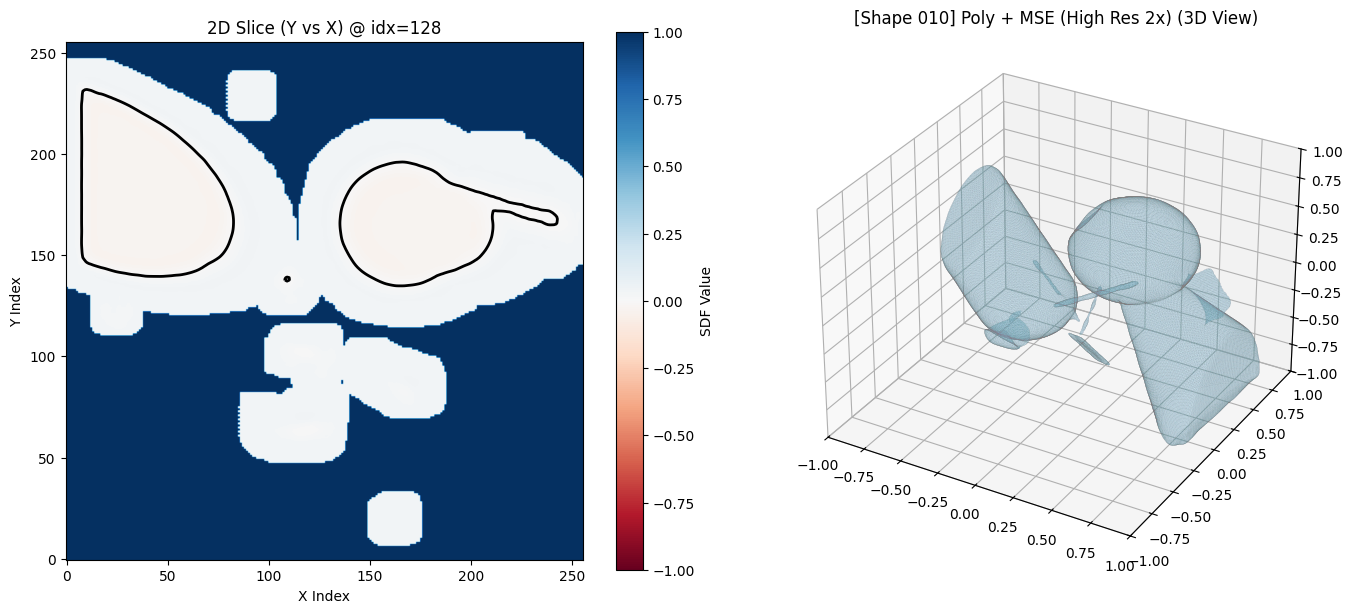

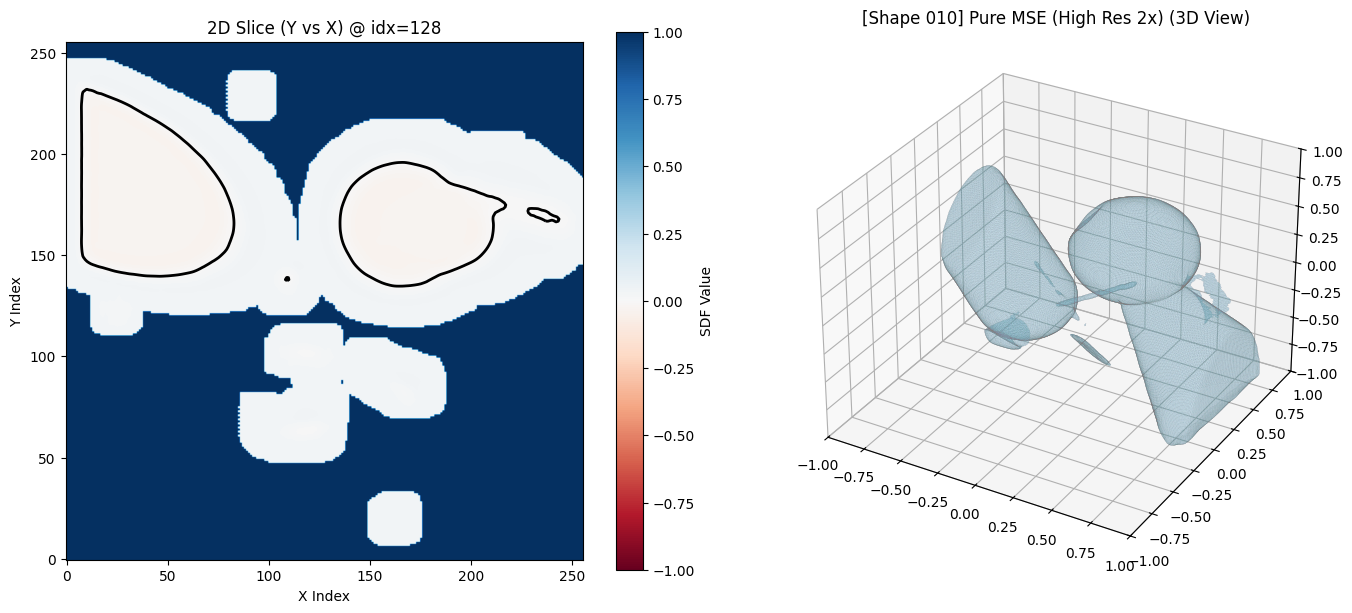

In [52]:
import time
import torch
import numpy as np

# ==========================================
# 🎯 [추가 실험] 특정 데이터 고해상도(Staggered) 추론 및 비교
# ==========================================
# 🚨 여기서 원하는 데이터의 인덱스 번호만 바꾸면 끝입니다! (예: 1, 9, 10)
target_idx = 10  

# 0을 채워서 자동으로 3자리 문자열로 만듭니다. (예: 1 -> "001", 15 -> "015")
shape_name = f"{target_idx:03d}" 

print("\n" + "="*55)
print(f">> 🎯 특정 테스트 데이터(Shape {shape_name}) 고해상도(2배) 추론 시작")
print("="*55)

# 1. 원본 파티클 데이터 & 정답 타겟 그리드 로드
# 🚨 핵심 변경: 이전처럼 mc_grid를 쓰지 않고, 최근 생성한 dataset4의 particles를 불러옵니다!
sdf_path = f"dataset4/sdf_grid_{shape_name}.npy"
particles_path = f"dataset4/particles_{shape_name}.npy"

target_sdf = np.load(sdf_path)          # (N, N, N) 기본 해상도 정답지
particles_np = np.load(particles_path)  # 원본 파티클 좌표

# 파티클을 텐서로 변환하여 GPU로 전송
particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)

# 2. [Poly 모드] 엇갈린 그리드(Staggered) 다중 추론 
print(f">> Poly 모델(정규화 ON)로 Shape {shape_name} 고해상도 뻥튀기 중...")
start_time = time.time()
pred_sdf_poly_high_res = reconstructor_poly.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# 3. [MSE 모드] 엇갈린 그리드(Staggered) 다중 추론
print(f">> MSE 모델(정규화 OFF)로 Shape {shape_name} 고해상도 뻥튀기 중...")
start_time = time.time()
pred_sdf_mse_high_res = reconstructor_mse.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 7] Shape {shape_name} 고해상도 결과물 시각화 ===")
print("💡 참고: Ground Truth는 기본 해상도(N)이며, 예측 결과는 2배 해상도(2N)입니다.")

# 1. 정답지 (기본 해상도)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Ground Truth (Base Res)"
)

# 2. 논문 세팅 결과 (2배 해상도 + 정규화로 매우 매끄러움)
visualize_simulation(
    sdf_grid=pred_sdf_poly_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Poly + MSE (High Res 2x)"
)

# 3. 정규화 끈 결과 (2배 해상도지만 표면이 울퉁불퉁할 수 있음)
visualize_simulation(
    sdf_grid=pred_sdf_mse_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Pure MSE (High Res 2x)"
)

## 4. SDF 값 시각화 (최종 결과)

4.2 obj로 저장(mc 알고리즘)

In [75]:
from modules.visualizer import save_mesh_as_obj # 시각화용
save_mesh_as_obj(target_sdf, filename="train_shape_128.obj")
save_mesh_as_obj(pred_sdf_grid, filename="test_shape_128.obj")

✅ 메쉬 저장 완료: train_shape_128.obj (Vertices: 69408)
✅ 메쉬 저장 완료: test_shape_128.obj (Vertices: 73494)


In [48]:
from modules.visualizer import save_mesh_as_obj # 시각화용
save_mesh_as_obj(pred_sdf_poly_high_res.cpu().numpy(), filename="pred_sdf_poly_high_res.obj")
save_mesh_as_obj(pred_sdf_mse_high_res.cpu().numpy(), filename="pred_sdf_mse_high_res.obj")

✅ 메쉬 저장 완료: pred_sdf_poly_high_res.obj (Vertices: 238724)
✅ 메쉬 저장 완료: pred_sdf_mse_high_res.obj (Vertices: 238736)


npy 파일 이용한 sdf 시각화

In [ ]:
from modules.visualizer import visualize_npy
# 2. 데이터 시각화 (Phase 2)
print("\n--- Phase 2: 시각화 및 저장 ---")

# SDF 파일 확인
visualize_npy("sdf_grid_64.npy")

# 파티클 파일 확인
visualize_npy("particles.npy")


변수(객체) 이용한 시각화(런타임에 있는 메모리)

In [ ]:
from modules.visualizer import visualize_simulation

# SDF만 보기 (기존 plot_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid)

# 파티클까지 겹쳐서 보기 (기존 plot_particles_and_sdf_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid, particles=particles)

obj 인터랙티브 뷰어

In [135]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("train_shape.obj")

🖥️ 3D 뷰어 실행 중: train_shape.obj ...
✅ 뷰어 종료됨.


In [136]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("test_shape.obj")

🖥️ 3D 뷰어 실행 중: test_shape.obj ...
✅ 뷰어 종료됨.


In [51]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("pred_sdf_poly.obj")

🖥️ 3D 뷰어 실행 중: pred_sdf_poly.obj ...
✅ 뷰어 종료됨.


In [50]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("pred_sdf_poly_high_res.obj")

🖥️ 3D 뷰어 실행 중: pred_sdf_poly_high_res.obj ...
✅ 뷰어 종료됨.
